In [44]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [46]:
cnn_model = load_model("/kaggle/input/models/sachinarkesh/ttesting/tensorflow2/default/1/cnn_model.h5")
mobilenet_model = load_model("/kaggle/input/models/sachinarkesh/ttesting/tensorflow2/default/1/mobilenet_model.h5")

In [52]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_dir = "/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/test"

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128,128),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

Found 2698 images belonging to 6 classes.


In [53]:
import numpy as np

test_generator.reset()

cnn_predictions = cnn_model.predict(test_generator)

cnn_pred_classes = np.argmax(cnn_predictions, axis=1)

169/169 ━━━━━━━━━━━━━━━━━━━━ 34s 200ms/step


In [54]:
test_generator.reset()

mobile_predictions = mobilenet_model.predict(test_generator)

mobile_pred_classes = np.argmax(mobile_predictions, axis=1)

169/169 ━━━━━━━━━━━━━━━━━━━━ 24s 133ms/step


In [55]:
true_classes = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print(class_names)

['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']


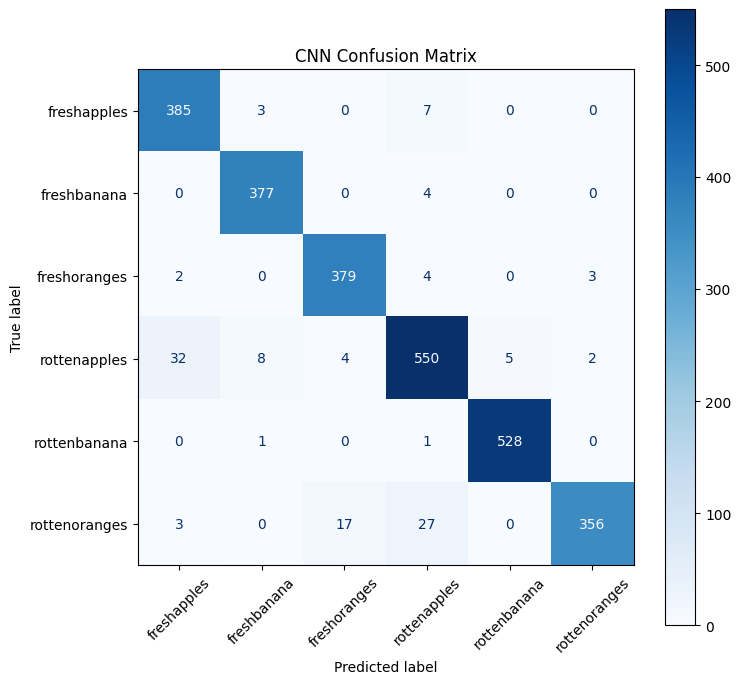

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_cnn = confusion_matrix(true_classes, cnn_pred_classes)

fig, ax = plt.subplots(figsize=(8,8))

ConfusionMatrixDisplay(
    confusion_matrix=cm_cnn,
    display_labels=class_names
).plot(ax=ax, cmap="Blues", xticks_rotation=45)

plt.title("CNN Confusion Matrix")
plt.show()

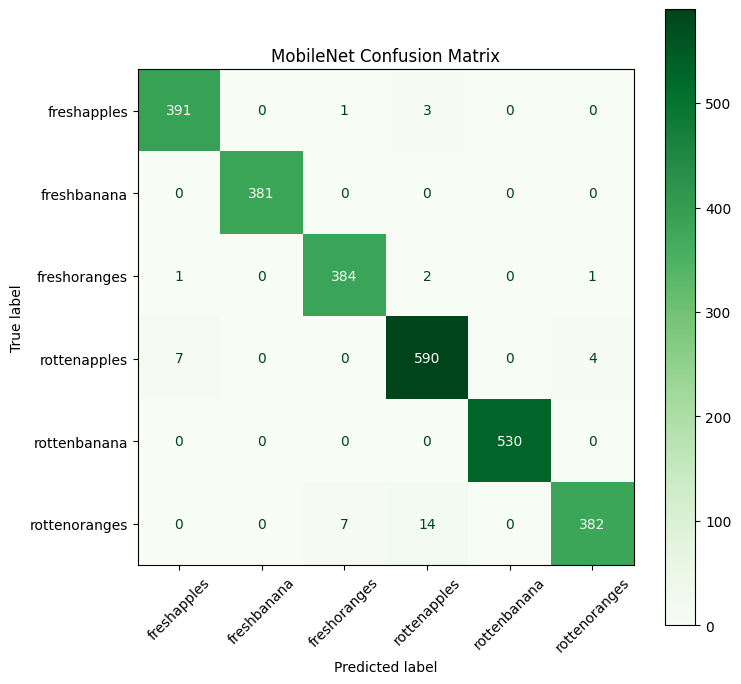

In [57]:
cm_mobile = confusion_matrix(true_classes, mobile_pred_classes)

fig, ax = plt.subplots(figsize=(8,8))

ConfusionMatrixDisplay(
    confusion_matrix=cm_mobile,
    display_labels=class_names
).plot(ax=ax, cmap="Greens", xticks_rotation=45)

plt.title("MobileNet Confusion Matrix")
plt.show()

In [58]:
from sklearn.metrics import classification_report

print("CNN Classification Report")
print(classification_report(
    true_classes,
    cnn_pred_classes,
    target_names=class_names
))

print("\n")

print("MobileNet Classification Report")
print(classification_report(
    true_classes,
    mobile_pred_classes,
    target_names=class_names
))

CNN Classification Report
               precision    recall  f1-score   support

  freshapples       0.91      0.97      0.94       395
  freshbanana       0.97      0.99      0.98       381
 freshoranges       0.95      0.98      0.96       388
 rottenapples       0.93      0.92      0.92       601
 rottenbanana       0.99      1.00      0.99       530
rottenoranges       0.99      0.88      0.93       403

     accuracy                           0.95      2698
    macro avg       0.96      0.96      0.96      2698
 weighted avg       0.96      0.95      0.95      2698



MobileNet Classification Report
               precision    recall  f1-score   support

  freshapples       0.98      0.99      0.98       395
  freshbanana       1.00      1.00      1.00       381
 freshoranges       0.98      0.99      0.98       388
 rottenapples       0.97      0.98      0.98       601
 rottenbanana       1.00      1.00      1.00       530
rottenoranges       0.99      0.95      0.97       403



In [59]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "CNN": [
        accuracy_score(true_classes, cnn_pred_classes),
        precision_score(true_classes, cnn_pred_classes, average="weighted"),
        recall_score(true_classes, cnn_pred_classes, average="weighted"),
        f1_score(true_classes, cnn_pred_classes, average="weighted")
    ],
    "MobileNet": [
        accuracy_score(true_classes, mobile_pred_classes),
        precision_score(true_classes, mobile_pred_classes, average="weighted"),
        recall_score(true_classes, mobile_pred_classes, average="weighted"),
        f1_score(true_classes, mobile_pred_classes, average="weighted")
    ]
})

comparison

,Metric,CNN,MobileNet
0,Accuracy,0.954411,0.985174
1,Precision,0.955193,0.985250
2,Recall,0.954411,0.985174
3,F1-Score,0.954171,0.985136


In [61]:
import os
import random

# Test dataset path
test_dir = "/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/test"

# Class names
class_names = sorted(os.listdir(test_dir))

# Collect all test images
all_images = []

for cls in class_names:
    cls_path = os.path.join(test_dir, cls)

    for img in os.listdir(cls_path):
        if img.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_images.append((os.path.join(cls_path, img), cls))

# Randomly select 10 images
random.shuffle(all_images)
sample_images = all_images[:10]

print("Total Sample Images:", len(sample_images))

Total Sample Images: 10


In [62]:
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing import image

results = []

for img_path, true_label in sample_images:

    # Load image
    img = image.load_img(img_path, target_size=(128,128))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # CNN Prediction
    cnn_pred = cnn_model.predict(img_array, verbose=0)
    cnn_label = class_names[np.argmax(cnn_pred)]
    cnn_conf = np.max(cnn_pred) * 100

    # MobileNet Prediction
    mobile_pred = mobilenet_model.predict(img_array, verbose=0)
    mobile_label = class_names[np.argmax(mobile_pred)]
    mobile_conf = np.max(mobile_pred) * 100

    results.append([
        img_path,
        true_label,
        cnn_label,
        round(cnn_conf,2),
        mobile_label,
        round(mobile_conf,2)
    ])

print("Prediction Completed Successfully!")

Prediction Completed Successfully!


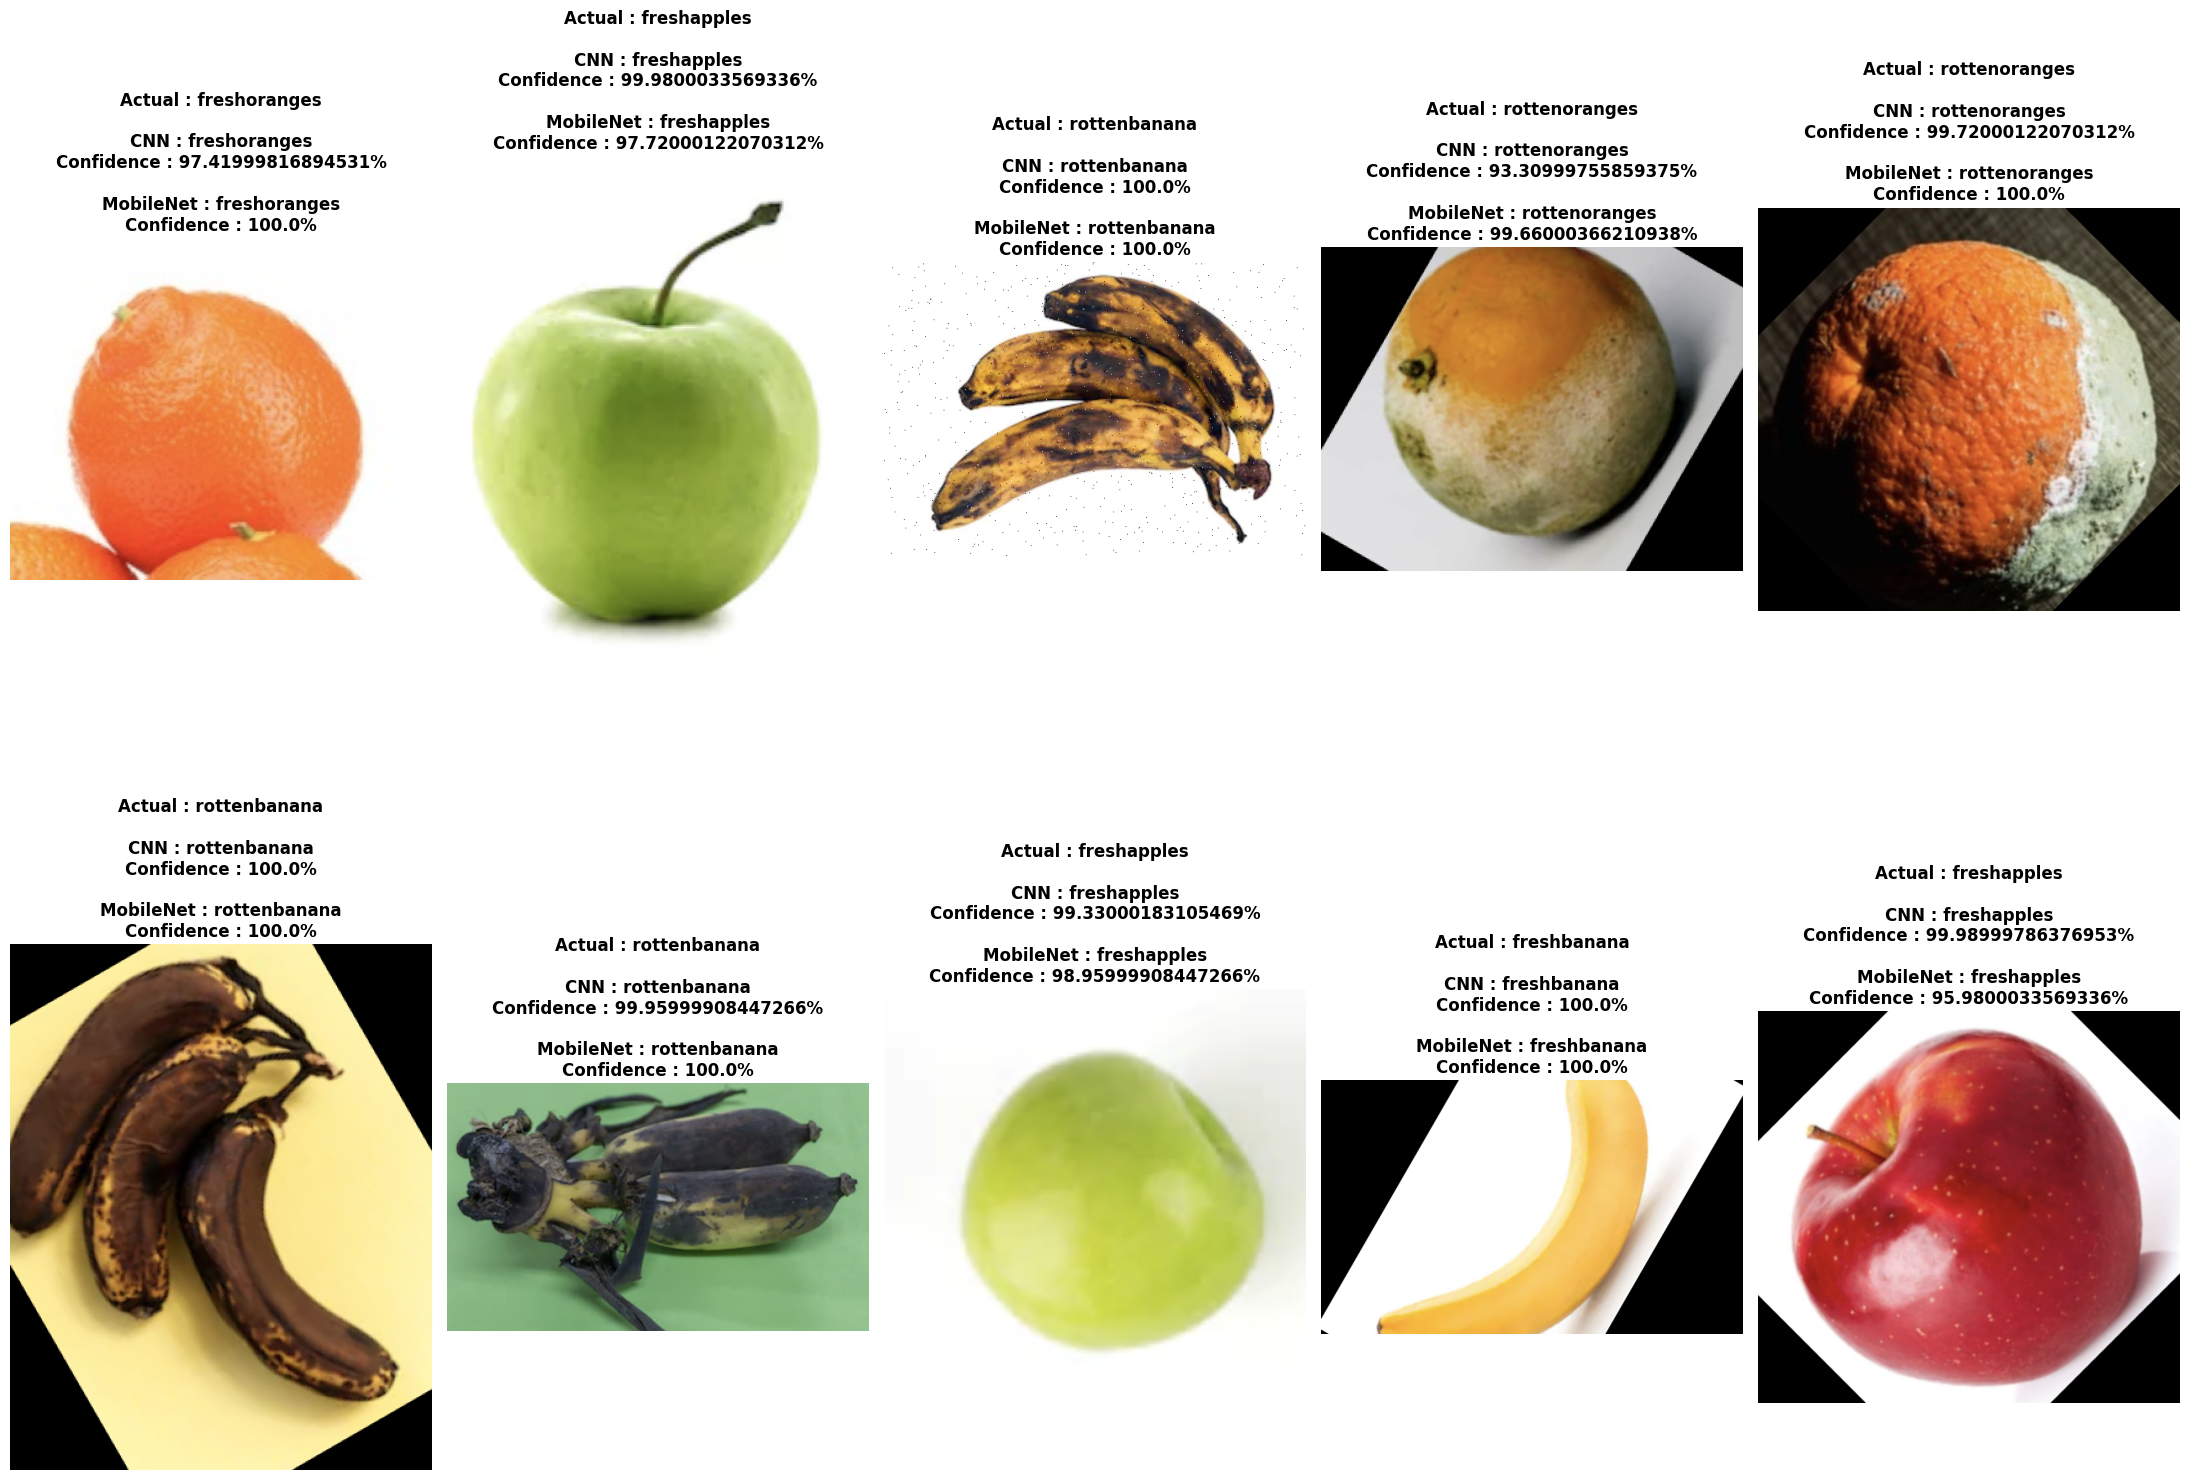

In [64]:
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(22,18))

for i, row in enumerate(results):

    img_path = row[0]
    actual = row[1]
    cnn = row[2]
    cnn_conf = row[3]
    mobile = row[4]
    mobile_conf = row[5]

    img = Image.open(img_path)

    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.axis("off")

    plt.title(
        f"Actual : {actual}\n\n"
        f"CNN : {cnn}\n"
        f"Confidence : {cnn_conf}%\n\n"
        f"MobileNet : {mobile}\n"
        f"Confidence : {mobile_conf}%",
        fontsize=12,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [65]:
# Create Comparison Table
comparison_df = pd.DataFrame(
    results,
    columns=[
        "Image Path",
        "Actual Label",
        "CNN Prediction",
        "CNN Confidence (%)",
        "MobileNet Prediction",
        "MobileNet Confidence (%)"
    ]
)

display(comparison_df)

,Image Path,Actual Label,CNN Prediction,CNN Confidence (%),MobileNet Prediction,MobileNet Confidence (%)
0,/kaggle/input/datasets/sriramr/fruits-fresh-an...,freshoranges,freshoranges,97.419998,freshoranges,100.000000
1,/kaggle/input/datasets/sriramr/fruits-fresh-an...,freshapples,freshapples,99.980003,freshapples,97.720001
2,/kaggle/input/datasets/sriramr/fruits-fresh-an...,rottenbanana,rottenbanana,100.000000,rottenbanana,100.000000
3,/kaggle/input/datasets/sriramr/fruits-fresh-an...,rottenoranges,rottenoranges,93.309998,rottenoranges,99.660004
4,/kaggle/input/datasets/sriramr/fruits-fresh-an...,rottenoranges,rottenoranges,99.720001,rottenoranges,100.000000
5,/kaggle/input/datasets/sriramr/fruits-fresh-an...,rottenbanana,rottenbanana,100.000000,rottenbanana,100.000000
6,/kaggle/input/datasets/sriramr/fruits-fresh-an...,rottenbanana,rottenbanana,99.959999,rottenbanana,100.000000
7,/kaggle/input/datasets/sriramr/fruits-fresh-an...,freshapples,freshapples,99.330002,freshapples,98.959999
8,/kaggle/input/datasets/sriramr/fruits-fresh-an...,freshbanana,freshbanana,100.000000,freshbanana,100.000000
9,/kaggle/input/datasets/sriramr/fruits-fresh-an...,freshapples,freshapples,99.989998,freshapples,95.980003


In [66]:
# Save Results
comparison_df.to_csv("Model_Comparison_Results.csv", index=False)

print("Comparison results saved as Model_Comparison_Results.csv")

Comparison results saved as Model_Comparison_Results.csv
